---
embed-resources: true
echo: false
warning: false
message: false
---

# PE Regression: Finding Undervalued S&P 500 Stocks

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

Section #1: Dataset
For this project, I chose to use financial data for almost every S&P 500 stock. I used the S&P Capital IQ platform to filter for S&P 500 stocks, exported the screen to excel, and converted the excel to a csv. The S&P 500 is an index of the largest and most significant ~500 stocks in the U.S. and is often used as a benchmark for the overall stock market. This dataset includes the ticker, security type, company name, trading price, primary sector, market capitalization, net income (earnings), revenue, capital expenditure, EBITDA (Earnings Before Interest, Taxes, Depreciation, and Amortization), and full time employees. I wanted to investigate how different stocks are valued by the market relative to these factors.
I cleaned up the data in this section to make it processable and dropped all companies that were unprofitable, lowering the total companies analyzed by around 60. All data as of 11/26/23.

In [3]:
# Load in DataFrame
df = pd.read_csv("DS Project.csv", encoding='latin-1')
df
# Clean DataFrame: drop all companies with negative earnings, EBITDA, capital expenditures for reliable data
df_unprofitable = df[df['Net Income [LTM] ($USDmm, Historical rate)'].str.contains("[()]")]
df.drop(df_unprofitable.index, inplace=True)
df = df.drop(columns=['In Process R&D Exp. [LTM] ($USDmm, Historical rate)'])
df_neg_ebitda = df[df['EBITDA [LTM] ($USDmm, Historical rate)'].str.contains("[()]")]
df.drop(df_neg_ebitda.index, inplace=True)
df_neg_capex = df[df['Capital Expenditure [LTM] ($USDmm, Historical rate)'].str.contains("[()]")]
df.drop(df_neg_capex.index, inplace=True)
df.astype('str')
df = df.replace(",","", regex=True)
# df.replace('(', '', regex=True)
df = df.replace("-","0", regex=True)
df.fillna(0, inplace=True)
df

In [4]:
df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'] = df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'].astype('float')
df['Net Income [LTM] ($USDmm, Historical rate)'] = df['Net Income [LTM] ($USDmm, Historical rate)'].fillna(0)
df['Net Income [LTM] ($USDmm, Historical rate)'] = df['Net Income [LTM] ($USDmm, Historical rate)'].astype('float')
df['As-Reported Total Revenue [LTM] ($USD, Historical rate)'] = df['As-Reported Total Revenue [LTM] ($USD, Historical rate)'].astype('float')
df['Capital Expenditure [LTM] ($USDmm, Historical rate)'] = df['Capital Expenditure [LTM] ($USDmm, Historical rate)'].astype('float')
df['EBITDA [LTM] ($USDmm, Historical rate)'] = df['EBITDA [LTM] ($USDmm, Historical rate)'].astype('float')
df['Full Time Employees [Latest Annual]'] = df['Full Time Employees [Latest Annual]'].astype('float')
df = df[df['EBITDA [LTM] ($USDmm, Historical rate)'] > 0]
df.dtypes

Ticker                                                              object
Security Name                                                       object
Company Name                                                        object
Most Recent Trade Price ($USD, Historical rate)                      object
Primary Sector                                                      object
Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)    float64
Net Income [LTM] ($USDmm, Historical rate)                          float64
As-Reported Total Revenue [LTM] ($USD, Historical rate)              float64
Capital Expenditure [LTM] ($USDmm, Historical rate)                 float64
EBITDA [LTM] ($USDmm, Historical rate)                              float64
Full Time Employees [Latest Annual]                                 float64
dtype: object

Section #2: Exploratory Data Science
Term Definitions:
- Net Income/Earnings: Cash left over after all expenses, "profit"
- Market capitalization: Total value of the stock, stock price * total shares outstanding
- Revenue: Income from selling goods
- EBITDA: Earnings Before Interest Taxes Depreciation Amortization, Net Income with some expenses excluded
- Multiple: Proportion of one financial metric relative to another, method of relative valuation
To begin, I created commonly used price multiples. I divided the market capitalization column by the earnings, EBITDA, and revenue columns to create three new multiples. The length of this dataset is 437 rows, meaning 437 stocks are included. The median Price/Earnings ratio is 23.48, the median Price/EBITDA ratio is 11.43, and the median Price/Revenue Ratio is 2.88. The descriptive data for all columns is below. In simple terms, I found these multiples by dividing the total value of the company's stock (market cap) by total revenue, EBITDA, or earnings. Net Income and earnings are synonymous. $MM means million dollars.

In [5]:
df.describe()

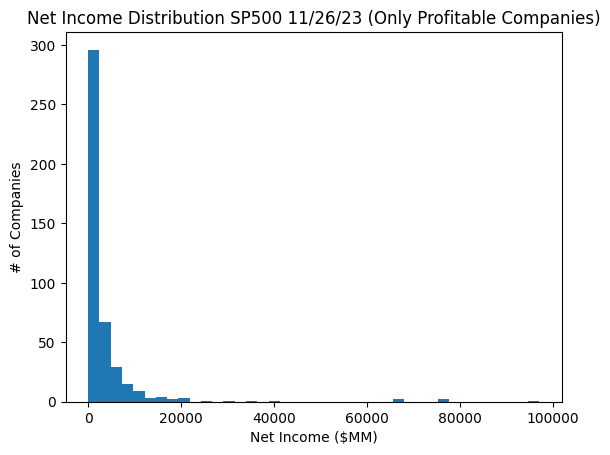

In [6]:
plt.title("Net Income Distribution SP500 11/26/23 (Only Profitable Companies)")
plt.xlabel("Net Income ($MM)")
plt.ylabel("# of Companies")
plt.hist(df['Net Income [LTM] ($USDmm, Historical rate)'], bins=40)

In [7]:
# Creating new columns, multiples
df['PE'] = df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)']/df['Net Income [LTM] ($USDmm, Historical rate)']
df['PEBITDA'] = df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)']/df['EBITDA [LTM] ($USDmm, Historical rate)']
revenue = df[df['As-Reported Total Revenue [LTM] ($USD, Historical rate)'] > 0]
df['PSALES'] = revenue['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)']/revenue['As-Reported Total Revenue [LTM] ($USD, Historical rate)']

In [8]:
PE_MED = df['PE'].median()
PEBITDA_MED = df['PEBITDA'].median()
PSALES_MED = df['PSALES'].median()
length = len(df)
length, PE_MED, PEBITDA_MED, PSALES_MED
# Number of stocks in dataset, price to earnings median, price to ebitda median, price to revenue median

(437, 23.48132803632236, 11.431161156364798, 2.8801911291160276)

In [9]:
df['Net Income [LTM] ($USDmm, Historical rate)'].describe() # Earnings descriptive statistics

In [10]:
df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'].describe() # Descriptive Statistics for market capitalization

Section #3: Data Visualization
To create a data visualization, I displayed the median Price to Earnings ratio of the S&P 500 constituent stocks in the dataset. PE ratios are used as a quick way of seeing if a stock is over or underpriced relative to its earnings. The higher a PE ratio is, the more overpriced the stock is relative to its earnings. To get this visualization, I grouped the PE values by primary sector and sorted it. After this, I established a bunch of parameters to customize the graph, and used matplotlib to create a bar chart of the values with sector on the x axis and median PE ratio on the y axis. Along with this, I made a yellow line that indicated the overall median.
From this graph, I discovered that the real estate had the highest median at over 35, with technology behind it, energy had the lowest at under 10. This is likely because the real estate and technology industries are expecting a lot of growth and innovation, while the largest companies in the energy industry are not expecting much near-term growth and is considered a volatile industry to invest in. The overall median PE is around 24, meaning that each of the S&P 500 stocks trade at a median of 24 times earnings.

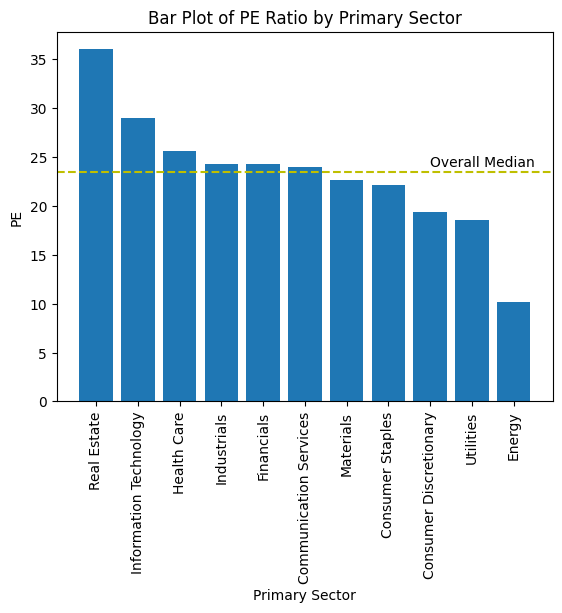

   Primary Sector            PE
9   Real Estate          36.009806
7   Information Technology  29.030280
5   Health Care          25.607947
6   Industrials          24.327149
4   Financials           24.265663
0   Communication Services  23.956890
8   Materials            22.690339
2   Consumer Staples     22.172518
1   Consumer Discretionary  19.389087
10  Utilities            18.599610
3   Energy               10.161505

In [11]:
sectors_median = df[["Primary Sector", "PE"]].groupby("Primary Sector").agg("median").reset_index()
sort_values = sectors_median.sort_values(by="PE", ascending=False)
plt.xticks(rotation='vertical')
overall_PE_med = df['PE'].median()
plt.axhline(overall_PE_med, color = "y", linestyle = '--')
plt.text(8, 24, "Overall Median")
plt.xlabel('Primary Sector')
plt.ylabel('PE')
plt.title('Bar Plot of PE Ratio by Primary Sector')
plt.bar(sectors_median['Primary Sector'], sectors_median['PE'])
sectors_median

Section #4: Data Science
PE ratios are used extremely often and are the golden standard for relative valuation, but exactly how strong is the correlation between price and earnings, and how does this correlation compare to other factors?
Since this market capitalization is price per share * total shares, I will use market capitalization / company earnings as PE ratio.
Market capitalization is what the market values the company, and earnings is synonymous with net income.

1. Earnings vs. Market Capitalization

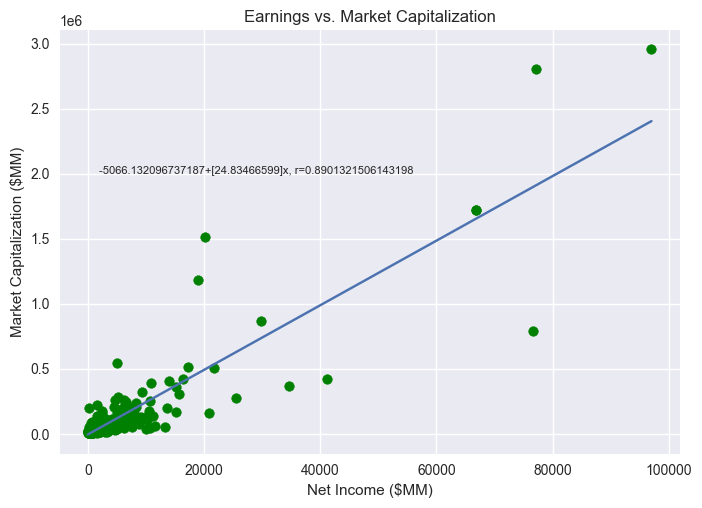

In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np
model = LinearRegression()
model.fit(df[["Net Income [LTM] ($USDmm, Historical rate)"]], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'])
a = model.intercept_
b = model.coef_
r = df["Net Income [LTM] ($USDmm, Historical rate)"].corr(df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'])
x = np.linspace(0, df["Net Income [LTM] ($USDmm, Historical rate)"].max())
y = a + b*x
# plt.style.use('seaborn')
plt.style.use("seaborn-v0_8")
plt.title("Earnings vs. Market Capitalization")
plt.plot(x, y)
plt.text(2000, 2000000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel("Net Income ($MM)")
plt.scatter(df["Net Income [LTM] ($USDmm, Historical rate)"], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'], color='g')

Earnings vs. Market Capitalization: Zoomed In

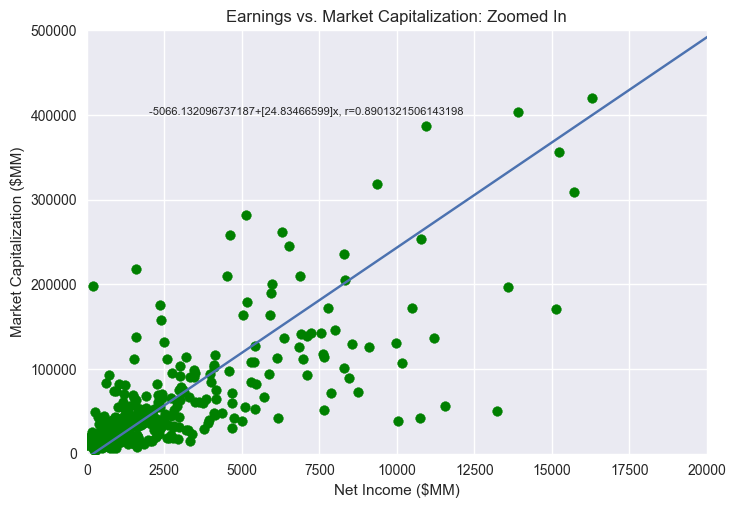

In [32]:
plt.style.use("seaborn-v0_8")
plt.title("Earnings vs. Market Capitalization: Zoomed In")
plt.plot(x, y)
plt.text(2000, 400000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel("Net Income ($MM)")
plt.scatter(df["Net Income [LTM] ($USDmm, Historical rate)"], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'], color='g')
plt.xlim(0, 20000)
plt.ylim(0, 0.5*10**6)
plt.show()

2. Revenue vs. Market Capitalization

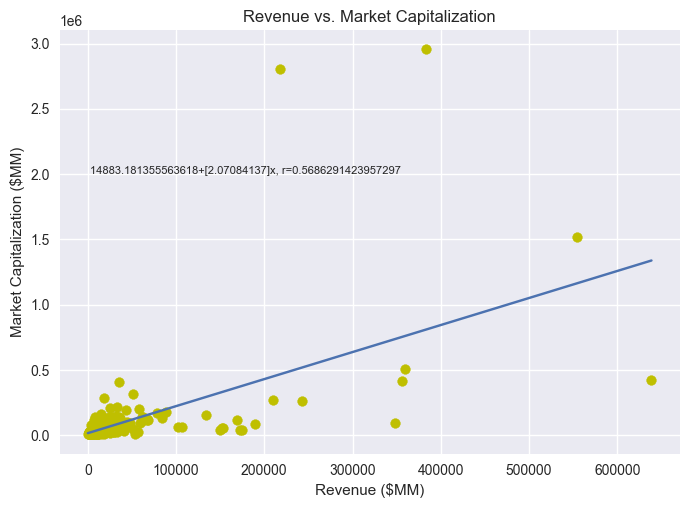

In [34]:
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns
model = LinearRegression()
model.fit(revenue[["As-Reported Total Revenue [LTM] ($USD, Historical rate)"]], revenue["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"])
a = model.intercept_
b = model.coef_
r = revenue["As-Reported Total Revenue [LTM] ($USD, Historical rate)"].corr(revenue["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"])
x = np.linspace(0, revenue["As-Reported Total Revenue [LTM] ($USD, Historical rate)"].max())
y = a + b*x
plt.style.use('seaborn-v0_8')
plt.title("Revenue vs. Market Capitalization")
plt.plot(x, y)
plt.text(2000, 2000000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel("Revenue ($MM)")
plt.scatter(revenue["As-Reported Total Revenue [LTM] ($USD, Historical rate)"], revenue["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"], color='y')

Revenue vs. Market Capitalization: Zoomed In

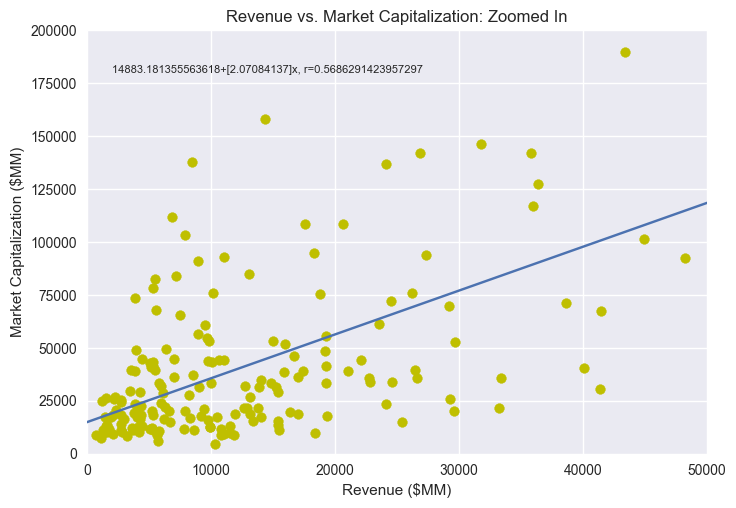

In [40]:
plt.style.use('seaborn-v0_8')
plt.title("Revenue vs. Market Capitalization: Zoomed In")
plt.plot(x, y)
plt.text(2000, 180000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel("Revenue ($MM)")
plt.xlim(0, 50000)
plt.ylim(0, 0.2*10**6)
plt.scatter(revenue["As-Reported Total Revenue [LTM] ($USD, Historical rate)"], revenue["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"], color='y')

3. Employees vs. Market Capitalization

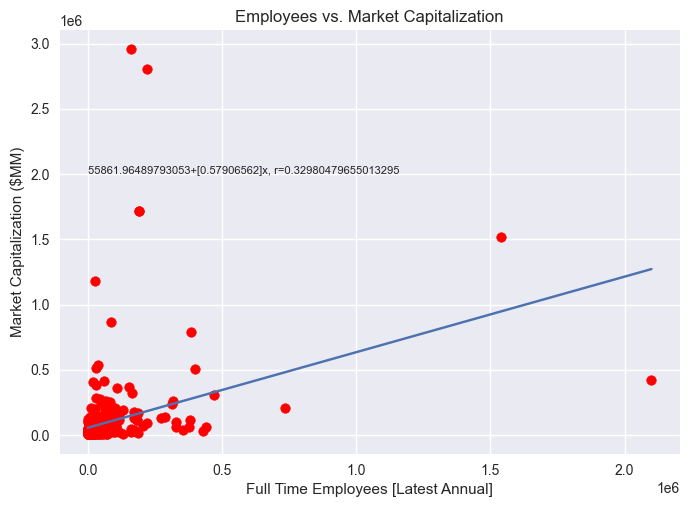

In [42]:
from sklearn.linear_model import LinearRegression
import numpy as np
x = "Full Time Employees [Latest Annual]"
model = LinearRegression()
model.fit(df[[x]], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'])
a = model.intercept_
b = model.coef_
r = df[x].corr(df["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"])
xx = np.linspace(0, df[x].max())
y = a + b*xx
# plt.style.use('seaborn')
plt.style.use("seaborn-v0_8")
plt.title("Employees vs. Market Capitalization")
plt.plot(xx, y)
plt.text(2000, 2000000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel(x)
plt.scatter(df[x], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'], color = 'r')

Employees vs. Market Capitalization: Zoomed In

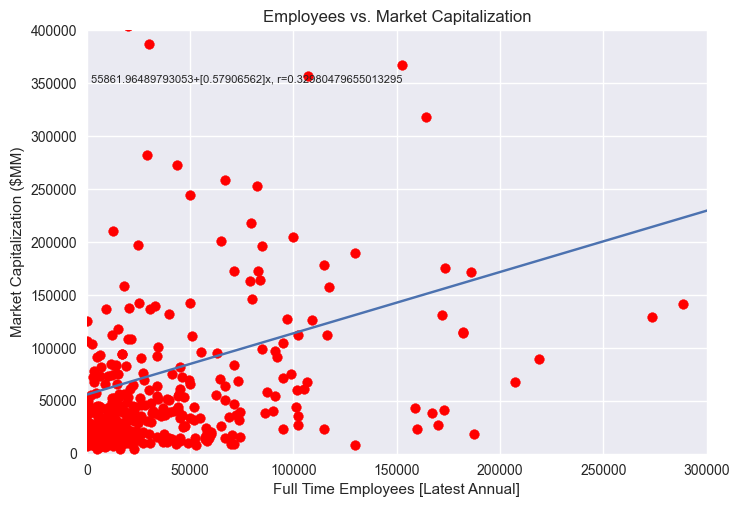

In [46]:
plt.style.use("seaborn-v0_8")
plt.title("Employees vs. Market Capitalization")
plt.plot(xx, y)
plt.text(2000, 350000, f"{a}+{b}x, r={r}", fontsize=8)
plt.ylabel("Market Capitalization ($MM)")
plt.xlabel(x)
plt.xlim(0, 0.3*10**6)
plt.ylim(0, 0.4*10**6)
plt.scatter(df[x], df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'], color = 'r')

4. Finding the Most Undervalued Company
Since earnings was the only strong correlation (r>0.75), I will use earnings for this analysis. First, I predicted the company's market capitalization based off of its earnings using the linear regression model. Then I created a residual column by subtracting the predicted value from the real value. After this, I made a new column that divided the residual by the market capitalization to make the values relative to the size of the company, and then I found the minimum of this column. Since market capitalization is essentially how the public market values the stock, the minimum of these values would represent the most undervalued stock, as this would be the one with the greatest relative difference between the model's valuation and the public's.

In [61]:
model = LinearRegression()
model.fit(df[["Net Income [LTM] ($USDmm, Historical rate)"]], df[["Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)"]])
df['PredictedFromEarnings'] = model.predict(df[['Net Income [LTM] ($USDmm, Historical rate)']])
df['Residual'] = df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)'] - df['PredictedFromEarnings']
df['Residual_Percentage'] = df['Residual']/df['Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)']
undervalued_stock = df.iloc[df['Residual_Percentage'].idxmin()]

Ticker                                                     NYSE:HD
Security Name                                          Common Stock
Company Name                                     The Home Depot Inc.
Most Recent Trade Price ($USD, Historical rate)                310.7
Primary Sector                                 Consumer Discretionary
Market Capitalization [My Setting] [Latest] ($USDmm, Historical rate)    309227.9
Net Income [LTM] ($USDmm, Historical rate)                      15704.0
As-Reported Total Revenue [LTM] ($USD, Historical rate)            0.0
Capital Expenditure [LTM] ($USDmm, Historical rate)             3271.0
EBITDA [LTM] ($USDmm, Historical rate)                         25472.0
Full Time Employees [Latest Annual]                           471600.0
PE                                                          19.691028
PEBITDA                                                     12.139914
PSALES                                                            NaN
Predicted

Based on this analysis, Home Depot Inc. (Ticker: HD) is the most undervalued stock in the S&P 500, and the model predicted its market capitalization would be 24% higher than it actually is. According to macrotrends.com, HD has 0.999B shares outstanding. Since stock price = market capitalization / total shares outstanding, this yields a predicted stock price of (384937/999) of $385, while the current stock price as of 11/26 is $310.

Section #5: Overall Summary
In this project, I used the S&P Capital IQ platform to export data about companies in the S&P 500 index. The S&P 500 index contains the ~500 largest and most significant companies/stocks in the United States. The metrics I analyzed were revenue, net income, EBITDA, total employees, and market capitalization. I cleaned up the data to only include profitable companies for this anal-ysis, and all data was accessed 11/26/23.
To create my visualization, I displayed the median Price/Earnings ratio of stocks by sector. In simple terms, P/E is just the company's market capitalization (market value) divided by the company's profit, and is the first tool used to value companies relative to other companies. The overall median P/E ratio was 24, and the highest sec-tor medians were Real Estate and technology, reflecting the market investment demand for these industries.
PE ratios are used extremely often and are the golden standard for relative valuation, but exactly how strong is the correlation between price and earnings, and how does this correlation compare to other factors? To solve this, I displayed three scatter and regression plots correlating market capitalization to each of these factors: net income, EBITDA, and total employees. All correlations were positive, however, net income was the only factor that displayed significant correlation at 0.89. After these three plots, I set out to find the most undervalued company based off of this. I created a residual column, then turned this residual into a percentage and found the lowest value. Home Depot Inc. had a predicted value 24% higher than its real value, meaning that based off of its earnings, Home Depot's stock is worth 24% more than its current price. This represents a great investment opportunity.